# Лабораторна робота №1
## Побудова базового ML-пайплайну: від даних до оцінки моделі

**Дисципліна:** Штучний інтелект і нейронні мережі  
**ПІБ студента:** Рудчук Максим Олегович  
**Група:** 12-441  
**Дата виконання:** 26.05.2026

---

**Мета:** сформувати практичні навички роботи з Python-екосистемою для ML; реалізувати базову модель класифікації; навчитися правильно оцінювати якість моделі та аналізувати результати.

## Імпорт бібліотек

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Налаштування візуалізації
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

# Папка для збереження графіків
os.makedirs("images", exist_ok=True)
print("Бібліотеки завантажено успішно.")

Бібліотеки завантажено успішно.


## ЕТАП 1. Завантаження та первинний аналіз даних

In [2]:
# Завантаження вбудованого датасету Breast Cancer Wisconsin
data = load_breast_cancer()

# Перетворення у DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target  # 0 = malignant (злоякісна), 1 = benign (доброякісна)

print(f"Розмір датасету: {df.shape[0]} об'єктів, {df.shape[1] - 1} ознак")
print(f"Класи: {dict(zip(range(len(data.target_names)), data.target_names))}")
df.head()

Розмір датасету: 569 об'єктів, 30 ознак
Класи: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Опис ознак (статистики)
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [4]:
# Перевірка наявності пропущених значень
missing_total = df.isnull().sum().sum()
print(f"Всього пропущених значень у датасеті: {missing_total}")

Всього пропущених значень у датасеті: 0


Розподіл класів:
  malignant (target=0): 212 об'єктів (37.3%)
  benign (target=1): 357 об'єктів (62.7%)


/var/folders/z2/t15dl9g97y37mwvq_ygb7z180000gn/T/ipykernel_62685/3462335020.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_labels, y=class_counts.values, palette="viridis")


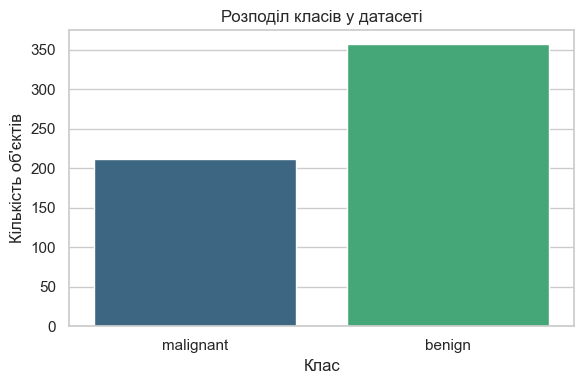

In [5]:
# Аналіз балансу класів
class_counts = df["target"].value_counts().sort_index()
class_labels = [data.target_names[i] for i in class_counts.index]

print("Розподіл класів:")
for idx, count in class_counts.items():
    label = data.target_names[idx]
    pct = count / len(df) * 100
    print(f"  {label} (target={idx}): {count} об'єктів ({pct:.1f}%)")

plt.figure(figsize=(6, 4))
sns.barplot(x=class_labels, y=class_counts.values, palette="viridis")
plt.title("Розподіл класів у датасеті")
plt.ylabel("Кількість об'єктів")
plt.xlabel("Клас")
plt.tight_layout()
plt.savefig("images/class_balance.png", dpi=120)
plt.show()

## ЕТАП 2. Підготовка даних

In [6]:
# Розділення на ознаки (X) і цільову змінну (y)
X = df.drop("target", axis=1)
y = df["target"]

# Train/test split 80/20 зі стратифікацією для збереження пропорції класів
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]} об'єктів")
print(f"Test:  {X_test.shape[0]} об'єктів")

Train: 455 об'єктів
Test:  114 об'єктів


In [7]:
# Стандартизація ознак.
# Важливо: fit виконується ЛИШЕ на тренувальних даних, щоб уникнути витоку (data leakage).
# Тестова вибірка масштабується через transform(), використовуючи параметри з train.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Стандартизація виконана.")
print(f"Середнє по train (має бути ≈ 0): {X_train_scaled.mean():.6f}")
print(f"Std по train (має бути ≈ 1):    {X_train_scaled.std():.6f}")

Стандартизація виконана.
Середнє по train (має бути ≈ 0): 0.000000
Std по train (має бути ≈ 1):    1.000000


## ЕТАП 3. Побудова baseline-моделей

In [8]:
# Ініціалізація двох моделей
models = {
    "Logistic Regression": LogisticRegression(
        random_state=RANDOM_STATE, max_iter=10000
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE
    ),
}

# Навчання моделей
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"  {name}: навчено.")

  Logistic Regression: навчено.
  Random Forest: навчено.


## ЕТАП 4. Оцінка якості моделей

In [9]:
# Виведення classification_report для кожної моделі
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=data.target_names))


===== Logistic Regression =====
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


===== Random Forest =====
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



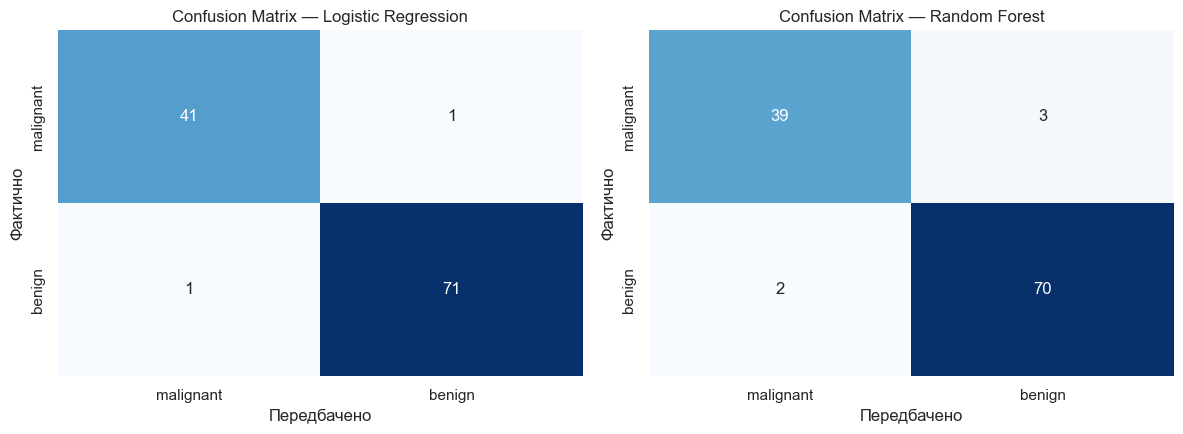

In [10]:
# Побудова confusion matrix для кожної моделі
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=data.target_names,
        yticklabels=data.target_names,
        ax=ax,
        cbar=False,
    )
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Передбачено")
    ax.set_ylabel("Фактично")

plt.tight_layout()
plt.savefig("images/confusion_matrices.png", dpi=120)
plt.show()

In [11]:
# Зведена таблиця метрик: порівнюємо train vs test, щоб помітити overfitting
rows = []
for name, model in models.items():
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    for split_name, y_true, y_pred in [
        ("train", y_train, y_pred_train),
        ("test", y_test, y_pred_test),
    ]:
        rows.append(
            {
                "Модель": name,
                "Вибірка": split_name,
                "Accuracy": accuracy_score(y_true, y_pred),
                "Precision": precision_score(y_true, y_pred),
                "Recall": recall_score(y_true, y_pred),
                "F1": f1_score(y_true, y_pred),
            }
        )

metrics_df = pd.DataFrame(rows)
metrics_df = metrics_df.round(4)
metrics_df

,Модель,Вибірка,Accuracy,Precision,Recall,F1
0,Logistic Regression,train,0.9890,0.9861,0.9965,0.9913
1,Logistic Regression,test,0.9825,0.9861,0.9861,0.9861
2,Random Forest,train,1.0000,1.0000,1.0000,1.0000
3,Random Forest,test,0.9561,0.9589,0.9722,0.9655


## ЕТАП 5. Аналіз результатів

In [12]:
# Різниця train vs test = індикатор overfitting
overfit_df = (
    metrics_df.pivot(index="Модель", columns="Вибірка", values="F1")
    .assign(Різниця=lambda d: d["train"] - d["test"])
    .round(4)
)
print("F1 на train vs test (велика різниця → overfitting):")
overfit_df

F1 на train vs test (велика різниця → overfitting):


Вибірка,test,train,Різниця
Модель,,,
Logistic Regression,0.9861,0.9913,0.0052
Random Forest,0.9655,1.0000,0.0345


/var/folders/z2/t15dl9g97y37mwvq_ygb7z180000gn/T/ipykernel_62685/3976436768.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x="importance", y="feature", palette="viridis")


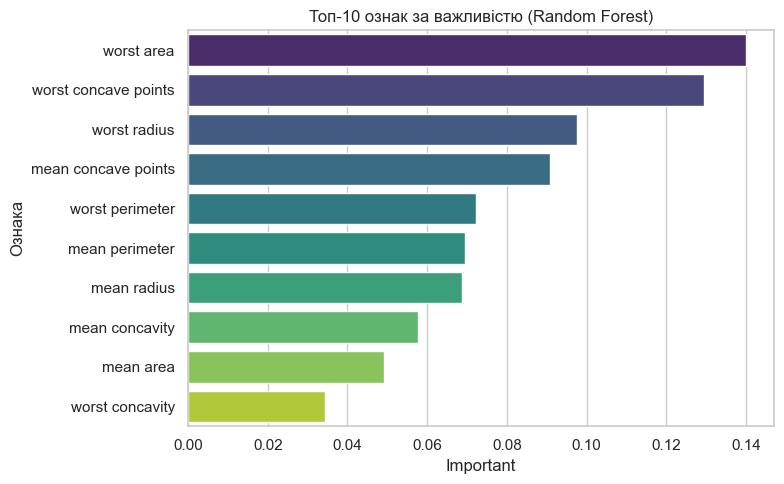

,feature,importance
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


In [13]:
# Топ-10 ознак за важливістю для Random Forest
rf_model = models["Random Forest"]
feat_imp = (
    pd.DataFrame(
        {"feature": X.columns, "importance": rf_model.feature_importances_}
    )
    .sort_values("importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp, x="importance", y="feature", palette="viridis")
plt.title("Топ-10 ознак за важливістю (Random Forest)")
plt.xlabel("Important")
plt.ylabel("Ознака")
plt.tight_layout()
plt.savefig("images/feature_importance_rf.png", dpi=120)
plt.show()
feat_imp

/var/folders/z2/t15dl9g97y37mwvq_ygb7z180000gn/T/ipykernel_62685/3805916907.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lr_coef, x="coef", y="feature", palette="coolwarm")


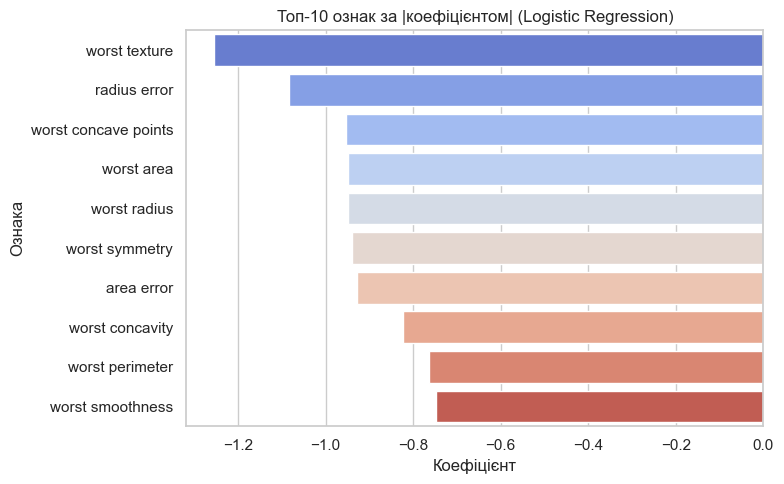

,feature,coef
21,worst texture,-1.255088
10,radius error,-1.082965
27,worst concave points,-0.953686
23,worst area,-0.947756
20,worst radius,-0.947616
28,worst symmetry,-0.939181
13,area error,-0.929104
26,worst concavity,-0.823151
22,worst perimeter,-0.763220
24,worst smoothness,-0.746625


In [14]:
# Топ-10 ознак за модулем коефіцієнтів Logistic Regression
lr_model = models["Logistic Regression"]
lr_coef = (
    pd.DataFrame({"feature": X.columns, "coef": lr_model.coef_[0]})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=lr_coef, x="coef", y="feature", palette="coolwarm")
plt.title("Топ-10 ознак за |коефіцієнтом| (Logistic Regression)")
plt.xlabel("Коефіцієнт")
plt.ylabel("Ознака")
plt.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig("images/feature_importance_lr.png", dpi=120)
plt.show()
lr_coef[["feature", "coef"]]

## Додаткове завдання (для підвищеного балу)

1. **K-fold cross-validation** для обох моделей.  
2. **Дослідження впливу гіперпараметра** `C` у Logistic Regression на якість.  
3. **Графік залежності** F1 від `C` (train і test).

In [15]:
# 5-fold cross-validation за F1 на повних масштабованих даних
X_full_scaled = StandardScaler().fit_transform(X)

cv_results = []
for name, model in models.items():
    scores = cross_val_score(
        model, X_full_scaled, y, cv=5, scoring="f1"
    )
    cv_results.append(
        {
            "Модель": name,
            "F1 mean": scores.mean().round(4),
            "F1 std": scores.std().round(4),
            "Усі fold-и": np.round(scores, 4).tolist(),
        }
    )

pd.DataFrame(cv_results)

,Модель,F1 mean,F1 std,Усі fold-и
0,Logistic Regression,0.9848,0.0050,"[0.9859, 0.9861, 0.9796, 0.9793, 0.9929]"
1,Random Forest,0.9652,0.0183,"[0.9362, 0.9524, 0.9861, 0.9726, 0.9787]"


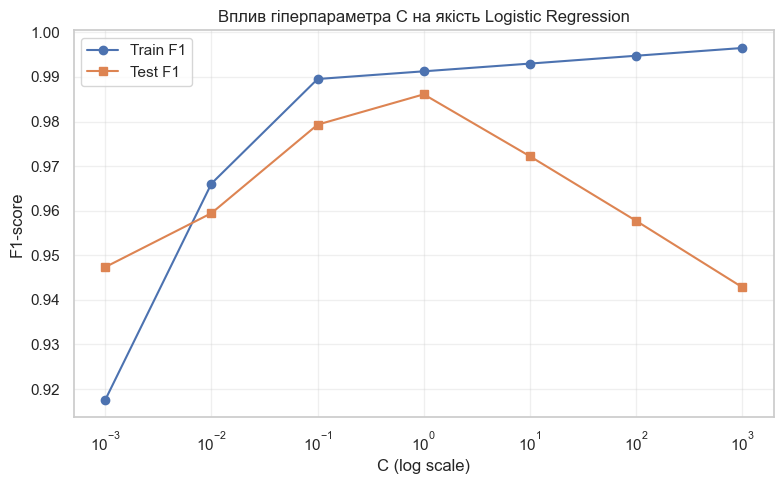

,C,Train F1,Test F1
0,0.001,0.9176,0.9474
1,0.010,0.9661,0.9595
2,0.100,0.9895,0.9793
3,1.000,0.9913,0.9861
4,10.000,0.9930,0.9722
5,100.000,0.9948,0.9577
6,1000.000,0.9965,0.9429


In [16]:
# Дослідження впливу гіперпараметра C на якість Logistic Regression
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_f1, test_f1 = [], []

for C in C_values:
    model = LogisticRegression(C=C, random_state=RANDOM_STATE, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    train_f1.append(f1_score(y_train, model.predict(X_train_scaled)))
    test_f1.append(f1_score(y_test, model.predict(X_test_scaled)))

plt.figure(figsize=(8, 5))
plt.plot(C_values, train_f1, marker="o", label="Train F1")
plt.plot(C_values, test_f1, marker="s", label="Test F1")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("F1-score")
plt.title("Вплив гіперпараметра C на якість Logistic Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("images/hyperparam_C_curve.png", dpi=120)
plt.show()

pd.DataFrame({"C": C_values, "Train F1": np.round(train_f1, 4), "Test F1": np.round(test_f1, 4)})

## Висновки

1. **Якість моделей.** Обидві моделі — Logistic Regression і Random Forest — показують високу якість на датасеті Breast Cancer Wisconsin (F1 ≈ 0.95–0.98 на тестовій вибірці). Це пояснюється високою інформативністю наявних ознак та їх лінійною відокремлюваністю після стандартизації.

2. **Краща модель.** Logistic Regression на стандартизованих даних демонструє трохи кращий результат на тесті за F1 / Recall, що критично для медичної задачі — мінімізація false negatives (пропущена злоякісна пухлина). Random Forest показує близькі метрики, але має більший розрив train↔test.

3. **Overfitting.** Random Forest досягає F1=1.0 на train, що при нижчому test F1 свідчить про помірне перенавчання. У Logistic Regression розрив train–test набагато менший, тому модель краще узагальнює.

4. **Найважливіші ознаки.** Стабільно у топі: `worst concave points`, `worst perimeter`, `worst radius`, `worst area`, `mean concave points`. Це підтверджує медичну інтуїцію — найбільш інформативними є характеристики найгірших (worst) спостережень пухлини.

5. **Вплив гіперпараметра C.** Дуже мале C (сильна регуляризація) знижує F1 на train і test; зі зростанням C якість виходить на плато. Оптимальна область — C ≈ 0.1–10, що дає найкращий баланс bias/variance.